#### 01 - EDA: Intel Image Classification Dataset
Цель: Провести разведочный анализ данных (EDA) датасета Intel Image Classification  
Задачи:  
1. Загрузить и проверить структуру данных
2. Визуализировать распределение классов
3. Показать примеры изображений из каждого класса
4. Проанализировать размеры изображений
5. Сделать выводы о качестве данных

In [2]:
import os
import random
from collections import Counter
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Настройки визуализации
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Пути к данным (предполагается, что датасет скачан и разархивирован)
DATA_DIR = Path('../data')
TRAIN_DIR = DATA_DIR / 'seg_train' / 'seg_train'
TEST_DIR = DATA_DIR / 'seg_test' / 'seg_test'

print(f'Путь к тренировочным данным: {TRAIN_DIR}')
print(f'Путь к тестовым данным: {TEST_DIR}')

Путь к тренировочным данным: ..\data\seg_train\seg_train
Путь к тестовым данным: ..\data\seg_test\seg_test


#### 1. Проверка структуры данных

In [4]:
def get_dataset_info(data_dir: Path):
    """
    Получим информацию о датасете: классы и количество изображений каждого класса
    """
    if not data_dir.exists():
        print(f'Директория {data_dir} не найдена!')
        print('Пожалуйста, скачайте датасет с Kaggle и разархивируйте в data/')
        return None, None
    
    classes = sorted([d.name for d in data_dir.iterdir() if d.is_dir()])
    class_counts = {}
    
    for cls in classes:
        cls_dir = data_dir / cls
        images = [f for f in cls_dir.iterdir() if f.suffix.lower() in ('.jpg', '.jpeg', '.png')]
        class_counts[cls] = len(images)
    
    return classes, class_counts

# Информация о тренировочном наборе
train_classes, train_counts = get_dataset_info(TRAIN_DIR)
print('Тренировочный набор')
if train_classes:
    print(f'Классы: {train_classes}')
    print(f'Всего изображений: {sum(train_counts.values())}')
    for cls, count in train_counts.items():
        print(f'  {cls}: {count}')

# Информация о тестовом наборе
test_classes, test_counts = get_dataset_info(TEST_DIR)
print('\n\nТестовый набор')
if test_classes:
    print(f'Классы: {test_classes}')
    print(f'Всего изображений: {sum(test_counts.values())}')
    for cls, count in test_counts.items():
        print(f'  {cls}: {count}')

Тренировочный набор
Классы: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Всего изображений: 14034
  buildings: 2191
  forest: 2271
  glacier: 2404
  mountain: 2512
  sea: 2274
  street: 2382


Тестовый набор
Классы: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Всего изображений: 3000
  buildings: 437
  forest: 474
  glacier: 553
  mountain: 525
  sea: 510
  street: 501


#### 2. Визуализация распределения классов

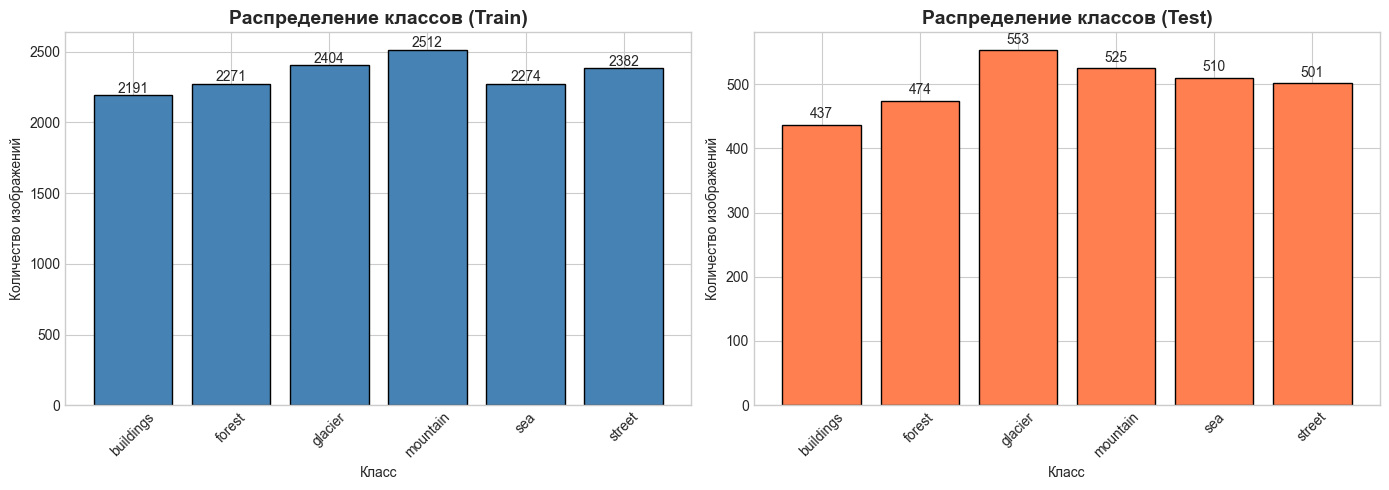

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Тренировочный набор
if train_classes:
    axes[0].bar(train_counts.keys(), train_counts.values(), color='steelblue', edgecolor='black')
    axes[0].set_title('Распределение классов (Train)', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Класс')
    axes[0].set_ylabel('Количество изображений')
    axes[0].tick_params(axis='x', rotation=45)
    for i, (cls, count) in enumerate(train_counts.items()):
        axes[0].text(i, count + 20, str(count), ha='center', fontsize=10)

# Тестовый набор
if test_classes:
    axes[1].bar(test_counts.keys(), test_counts.values(), color='coral', edgecolor='black')
    axes[1].set_title('Распределение классов (Test)', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Класс')
    axes[1].set_ylabel('Количество изображений')
    axes[1].tick_params(axis='x', rotation=45)
    for i, (cls, count) in enumerate(test_counts.items()):
        axes[1].text(i, count + 10, str(count), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../artifacts/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

#### 3. Примеры изображений из каждого класса

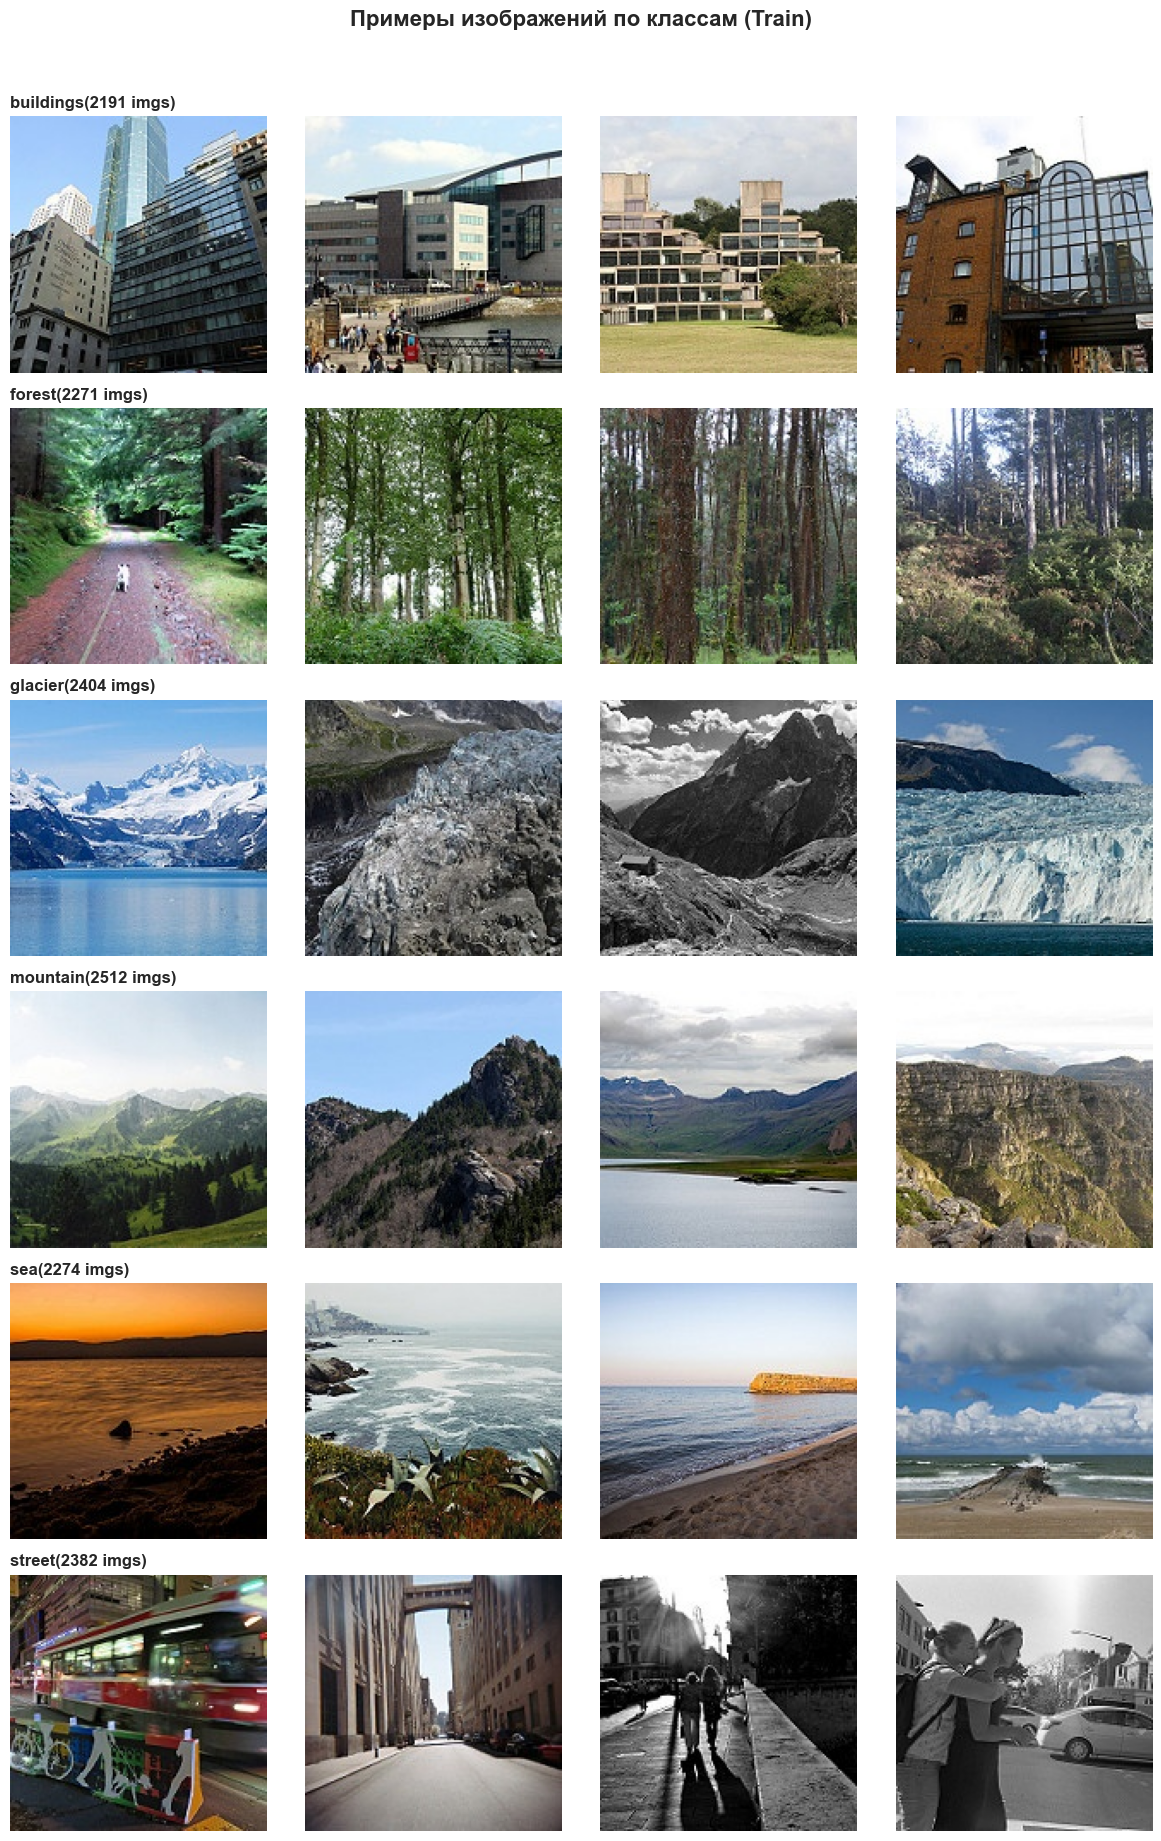

In [ ]:
def show_class_samples(data_dir: Path, classes: list, samples_per_class: int = 4):
    """
    Отображение примеры изображений из каждого класса.
    """
    if not classes:
        print('Нет данных для отображения')
        return
    
    n_classes = len(classes)
    fig, axes = plt.subplots(n_classes, samples_per_class, figsize=(samples_per_class * 3, n_classes * 3))
    
    for i, cls in enumerate(classes):
        cls_dir = data_dir / cls
        images = list(cls_dir.glob('*.jpg')) + list(cls_dir.glob('*.jpeg')) + list(cls_dir.glob('*.png'))
        
        # Выбираем случайные изображения
        selected = random.sample(images, min(samples_per_class, len(images)))
        
        for j, img_path in enumerate(selected):
            img = Image.open(img_path)
            axes[i, j].imshow(img)
            axes[i, j].axis('off')
            if j == 0:
                axes[i, j].set_title(f'{cls}({len(images)} imgs)', fontsize=12, fontweight='bold', loc='left')
    
    plt.suptitle('Примеры изображений по классам (Train)', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('../artifacts/class_samples.png', dpi=150, bbox_inches='tight')
    plt.show()

show_class_samples(TRAIN_DIR, train_classes)

#### 4. Анализ размеров изображений

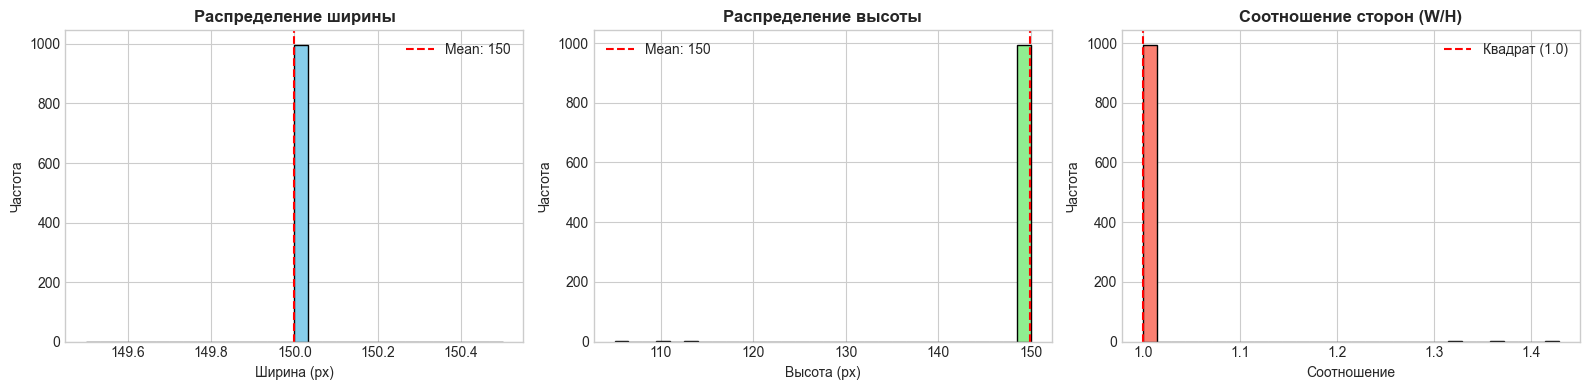

Статистика размеров изображений:
Уникальные размеры: 4
Самый частый размер: ((150, 150), 993)
Мин/Макс ширина: 150 / 150
Мин/Макс высота: 105 / 150


In [7]:
def analyze_image_sizes(data_dir: Path, max_samples: int = 1000):
    """
    Анализ размеров изображений в датасете
    """
    widths, heights = [], []
    
    for cls_dir in data_dir.iterdir():
        if not cls_dir.is_dir():
            continue
        images = list(cls_dir.glob('*.jpg')) + list(cls_dir.glob('*.jpeg')) + list(cls_dir.glob('*.png'))
        for img_path in images[:max_samples // 6]:  # ~равномерно по классам
            with Image.open(img_path) as img:
                widths.append(img.width)
                heights.append(img.height)
    
    return widths, heights

if TRAIN_DIR.exists():
    widths, heights = analyze_image_sizes(TRAIN_DIR)
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    
    # Распределение ширины
    axes[0].hist(widths, bins=30, color='skyblue', edgecolor='black')
    axes[0].set_title('Распределение ширины', fontweight='bold')
    axes[0].set_xlabel('Ширина (px)')
    axes[0].set_ylabel('Частота')
    axes[0].axvline(np.mean(widths), color='red', linestyle='--', label=f'Mean: {np.mean(widths):.0f}')
    axes[0].legend()
    
    # Распределение высоты
    axes[1].hist(heights, bins=30, color='lightgreen', edgecolor='black')
    axes[1].set_title('Распределение высоты', fontweight='bold')
    axes[1].set_xlabel('Высота (px)')
    axes[1].set_ylabel('Частота')
    axes[1].axvline(np.mean(heights), color='red', linestyle='--', label=f'Mean: {np.mean(heights):.0f}')
    axes[1].legend()
    
    # Соотношение сторон
    ratios = [w/h for w, h in zip(widths, heights)]
    axes[2].hist(ratios, bins=30, color='salmon', edgecolor='black')
    axes[2].set_title('Соотношение сторон (W/H)', fontweight='bold')
    axes[2].set_xlabel('Соотношение')
    axes[2].set_ylabel('Частота')
    axes[2].axvline(1.0, color='red', linestyle='--', label='Квадрат (1.0)')
    axes[2].legend()
    
    plt.tight_layout()
    plt.savefig('../artifacts/image_sizes_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f'Статистика размеров изображений:')
    print(f'Уникальные размеры: {len(set(zip(widths, heights)))}')
    print(f'Самый частый размер: {Counter(zip(widths, heights)).most_common(1)[0]}')
    print(f'Мин/Макс ширина: {min(widths)} / {max(widths)}')
    print(f'Мин/Макс высота: {min(heights)} / {max(heights)}')

#### 5. Анализ яркости и цветового распределения

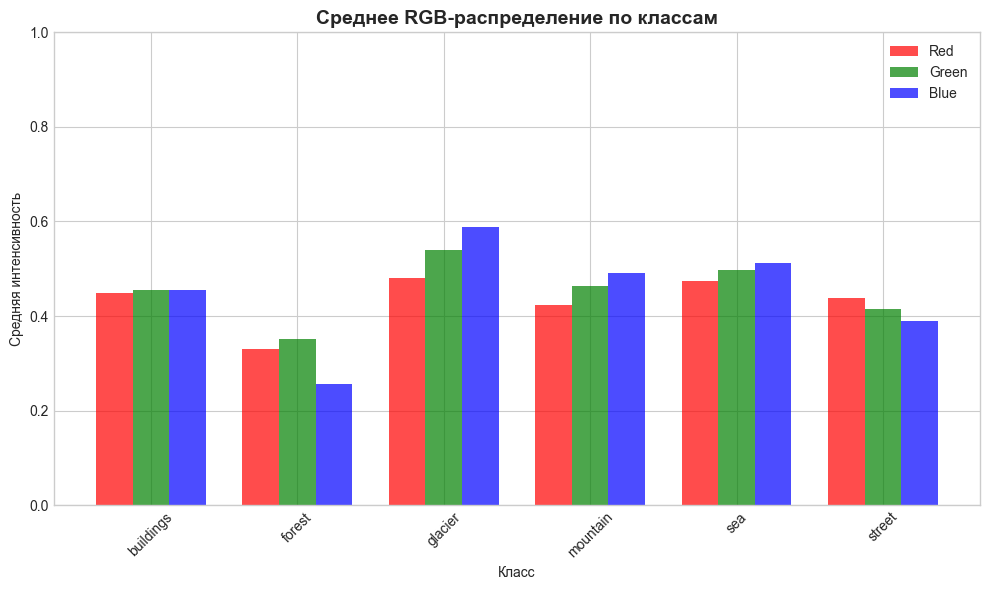

In [8]:
def analyze_color_distribution(data_dir: Path, classes: list, samples_per_class: int = 50):
    """
    Анализ среднего цвета по классам.
    """
    class_colors = {cls: [] for cls in classes}
    
    for cls in classes:
        cls_dir = data_dir / cls
        images = list(cls_dir.glob('*.jpg')) + list(cls_dir.glob('*.jpeg')) + list(cls_dir.glob('*.png'))
        selected = random.sample(images, min(samples_per_class, len(images)))
        
        for img_path in selected:
            img = np.array(Image.open(img_path).resize((64, 64))) / 255.0
            class_colors[cls].append(img.mean(axis=(0, 1)))  # Средний RGB
    
    # Визуализация
    fig, ax = plt.subplots(figsize=(10, 6))
    x = np.arange(len(classes))
    width = 0.25
    
    r_means = [np.mean([c[0] for c in class_colors[cls]]) for cls in classes]
    g_means = [np.mean([c[1] for c in class_colors[cls]]) for cls in classes]
    b_means = [np.mean([c[2] for c in class_colors[cls]]) for cls in classes]
    
    ax.bar(x - width, r_means, width, label='Red', color='red', alpha=0.7)
    ax.bar(x, g_means, width, label='Green', color='green', alpha=0.7)
    ax.bar(x + width, b_means, width, label='Blue', color='blue', alpha=0.7)
    
    ax.set_xlabel('Класс')
    ax.set_ylabel('Средняя интенсивность')
    ax.set_title('Среднее RGB-распределение по классам', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(classes, rotation=45)
    ax.legend()
    ax.set_ylim(0, 1)
    
    plt.tight_layout()
    plt.savefig('../artifacts/color_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()

if train_classes:
    analyze_color_distribution(TRAIN_DIR, train_classes)

#### 6. Выводы по EDA

#### Основные наблюдения:

1. Сбалансированность: классы в целом сбалансированы, но есть небольшой перекос в mountain (2512) и glacier (2404). Они чуть больше, чем например тот же класс buildings (2191). Разница в целом не критичная, но стоит иметь в виду. Аccuracy может быть чуть завышена за счёт данного перевеса

2. Размеры: почти все изображения 150×150, но встречаются и другие размеры (например, высота 105 px). Это значит, что ресайз до 224×224 необходим - иначе модель сломается на батче с разными размерами

3. Визуальная различимость: Классы вроде бы различимы, но при ближайшем рассмотрении есть проблемные пары:
   - `glacier` и `mountain` (оба снег и скалы, граница чуть размыта)
   - `buildings` и `street` (городская среда, здания часто попадают в кадр улицы)

4. Цветовые особенности:
   - `forest` - самый низкий общий уровень яркости, преобладание зелёного (логично, не правда ли?)
   - `sea` - преобладание синего
   - `glacier` - высокая яркость (белый снег + голубой лёд)
   - `street` - более тусклые тона, преобладание серого/коричневого
